In [ ]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_splitw
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import keras
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def histogram(y_train, type):
    label_names = {
        0: "No Metastasis",
        1: "Bone",
        2: "Liver",
        3: "Lung",
        4: "Nervous"
    }

    label_counts = np.bincount(y_train)
    labels = np.arange(len(label_counts))
    names = [label_names[i] for i in labels]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, label_counts, color='skyblue', edgecolor='black')

    for bar, count in zip(bars, label_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 1, str(count),
                ha='center', va='bottom', fontsize=10)

    if type == 0:
        plt.title("Histogram of Y_train (before SMOTE)")
    else:
        plt.title("Histogram of Y_train (after SMOTE)")

    plt.xlabel("Cancer Type")
    plt.ylabel("Number of Patients")
    plt.xticks(labels, names, rotation=15)
    plt.ylim(0, max(label_counts) * 1.15)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()

    plt.show()

,200082_s_at,201254_x_at,208703_s_at,209109_s_at,212146_at,213521_at,217092_x_at,35685_at,43544_at,Characteristics..Relapse..Metastasis.Bone.
0,-1.672683,-1.986030,-1.582285,-1.295204,1.217307,-0.139482,-0.317072,0.691321,0.165847,1
1,-3.602156,-2.489138,-1.393338,-1.373706,1.034277,-0.128412,-0.020898,-0.055973,0.897427,1
2,-3.720211,-1.836193,-1.352381,-1.740283,1.623132,1.428943,-1.068299,1.655373,2.281557,0
3,-3.844653,-1.503930,-2.425572,-1.772924,1.102629,3.198151,-3.446621,1.016217,1.950300,1
4,-1.581204,-0.270695,-0.785472,-1.126815,0.618419,0.632218,-2.389388,2.479340,1.599062,1
...,...,...,...,...,...,...,...,...,...,...
395,0.531485,-0.772830,-1.082658,0.447496,0.359505,-0.378948,-0.509532,0.171873,-0.398757,0
396,-0.379483,0.298304,0.890963,-0.451739,0.621588,-0.044738,0.025433,1.589607,-0.237291,0
397,-0.972971,-0.785860,1.208485,1.567621,-1.434764,0.039073,-0.880764,-0.800062,-0.142271,0
398,2.342499,0.048552,0.392869,0.692672,-0.562145,-1.298850,1.461703,-0.403791,0.108381,0


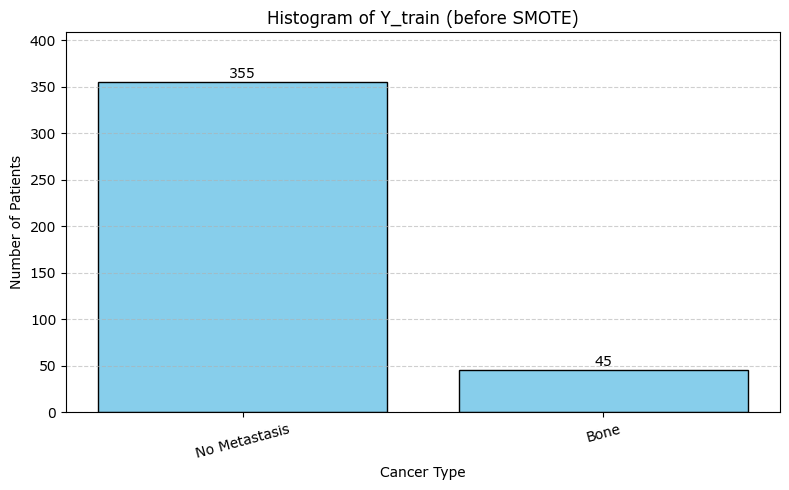

(280,)
(44,)
(76,)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Load dataset
# data_path = r"C:\Users\Win\Documents\Github Workspace\Machine_Learning\Project\New Data.csv"
# data_path = r"C:\Users\Win\Documents\Github Workspace\Machine_Learning\Project\Machine Learning Cancer - Data - Sheet1.csv"
# data_path = r"C:\Users\Win\Documents\Github Workspace\Machine_Learning\Project\emtab_9genes_bone.csv"
# data_path = r"C:\Users\Win\Documents\Github Workspace\Machine_Learning\Project\gse2034_9genes_bone.csv"
# data_path = r"C:\Users\Win\Documents\Github Workspace\Machine_Learning\Project\gse2603_9genes_bone.csv"
data_path = r"C:\Users\Win\Documents\Github Workspace\Machine_Learning\Project\Machine Learning Cancer Prediction - New Data Bone - Only (1).csv"
data = pd.read_csv(data_path, delimiter=",")

display(data)

X = data.iloc[:, :-1]       
y = data.iloc[:, -1].astype(int)  

histogram(y, 0)
smote = SMOTE(random_state=42, k_neighbors=5)
# X, y = smote.fit_resample(X, y)
# histogram(y, 1)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

X_cv, X_test, y_cv, y_test = train_test_split(
    X_temp, y_temp, test_size=0.63, random_state=42, stratify=y_temp)

np.bincount(y_train)
print(y_train.shape)
print(y_cv.shape)
print(y_test.shape)

In [13]:
import pandas as pd
from itertools import combinations
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score,
    f1_score, accuracy_score
)

# gene_names = ['217092_x_at', '43544_at']
gene_names = ['200082_s_at', '201254_x_at', '208703_s_at', '209109_s_at', '212146_at', '213521_at', '217092_x_at',	'35685_at', '43544_at']

X_train = pd.DataFrame(X_train, columns=gene_names)
X_cv = pd.DataFrame(X_cv, columns=gene_names)
X_test = pd.DataFrame(X_test, columns=gene_names)

all_results = []
n_classes = len(set(y_train))

for k in range(1, len(gene_names) + 1):
    for comb in combinations(gene_names, k):
        features = list(comb)

        X_train_sel = X_train[features]
        X_cv_sel = X_cv[features]
        X_test_sel = X_test[features]

        model = LogisticRegression(max_iter=1000)
        model.fit(X_train_sel, y_train)

        y_train_pred = model.predict(X_train_sel)
        y_cv_pred = model.predict(X_cv_sel)
        y_test_pred = model.predict(X_test_sel)
        y_test_proba = model.predict_proba(X_test_sel)

        try:
            if n_classes > 2:
                auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
            else:
                auc = roc_auc_score(y_test, y_test_proba[:, 1])
        except:
            auc = float('-inf')

        recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
        precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
        train_acc = accuracy_score(y_train, y_train_pred)
        cv_acc = accuracy_score(y_cv, y_cv_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        all_results.append({
            "genes": ' + '.join(features),
            "auc": auc,
            "recall": recall,
            "precision": precision,
            "f1": f1,
            "train_acc": train_acc,
            "cv_acc": cv_acc,
            "test_acc": test_acc
        })

results_df = pd.DataFrame(all_results)

summary_rows = []
metrics = {
    "Highest AUC": "auc",
    "Highest Recall": "recall",
    "Highest Precision": "precision",
    "Highest F1-score": "f1",
    "Highest Train Accuracy": "train_acc",
    "Highest CV Accuracy": "cv_acc",
    "Highest Test Accuracy": "test_acc"
}

for label, metric in metrics.items():
    best_row = results_df.loc[results_df[metric].idxmax()]
    summary_rows.append({
        "Metric": label,
        "Genes": best_row["genes"],
        "AUC": best_row["auc"],
        "Recall": best_row["recall"],
        "Precision": best_row["precision"],
        "F1-score": best_row["f1"],
        "Train Accuracy": best_row["train_acc"],
        "CV Accuracy": best_row["cv_acc"],  
        "Test Accuracy": best_row["test_acc"]
    })
    
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("SMOTE + LR + Multiclass.csv", index=False)
print("✅ Summary saved to 'Logistic Regression.csv'")

✅ Summary saved to 'Logistic Regression.csv'


In [ ]:


gene_names = ['200082_s_at', '201254_x_at', '208703_s_at', '209109_s_at', '212146_at', '213521_at', '217092_x_at', '35685_at', '43544_at']

X_train = pd.DataFrame(X_train, columns=gene_names)
X_cv = pd.DataFrame(X_cv, columns=gene_names)
X_test = pd.DataFrame(X_test, columns=gene_names)

all_results = []
n_classes = len(set(y_train))

for k in range(1, len(gene_names) + 1):
    for comb in combinations(gene_names, k):
        features = list(comb)

        X_train_sel = X_train[features]
        X_cv_sel = X_cv[features]
        X_test_sel = X_test[features]

        model = LogisticRegression(max_iter=1000)
        model.fit(X_train_sel, y_train)

        # Predictions
        y_train_pred = model.predict(X_train_sel)
        y_cv_pred = model.predict(X_cv_sel)
        y_test_pred = model.predict(X_test_sel)

        # Probabilities
        y_train_proba = model.predict_proba(X_train_sel)
        y_cv_proba = model.predict_proba(X_cv_sel)
        y_test_proba = model.predict_proba(X_test_sel)

        # AUC scores
        try:
            if n_classes > 2:
                train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr', average='macro')
                cv_auc = roc_auc_score(y_cv, y_cv_proba, multi_class='ovr', average='macro')
                test_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
            else:
                train_auc = roc_auc_score(y_train, y_train_proba[:, 1])
                cv_auc = roc_auc_score(y_cv, y_cv_proba[:, 1])
                test_auc = roc_auc_score(y_test, y_test_proba[:, 1])
        except:
            train_auc = cv_auc = test_auc = float('-inf')

        # Accuracy
        train_acc = accuracy_score(y_train, y_train_pred)
        cv_acc = accuracy_score(y_cv, y_cv_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        # Other metrics on TEST
        recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
        precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

        # print(f"Genes: {' + '.join(features)}")
        # print(f"Train AUC: {train_auc:.4f}, CV AUC: {cv_auc:.4f}, Test AUC: {test_auc:.4f}")
        # print(f"Train Acc: {train_acc:.4f}, CV Acc: {cv_acc:.4f}, Test Acc: {test_acc:.4f}\n")

        all_results.append({
            "genes": ' + '.join(features),
            "train_auc": train_auc,
            "cv_auc": cv_auc,
            "test_auc": test_auc,
            "recall": recall,
            "precision": precision,
            "f1": f1,
            "train_acc": train_acc,
            "cv_acc": cv_acc,
            "test_acc": test_acc
        })

# Save results
results_df = pd.DataFrame(all_results)

# Summary of best performing combinations
summary_rows = []
metrics = {
    "Highest Train AUC": "train_auc",
    "Highest CV AUC": "cv_auc",
    "Highest Test AUC": "test_auc",
    "Highest Recall": "recall",
    "Highest Precision": "precision",
    "Highest F1-score": "f1",
    "Highest Train Accuracy": "train_acc",
    "Highest CV Accuracy": "cv_acc",
    "Highest Test Accuracy": "test_acc"
}

for label, metric in metrics.items():
    best_row = results_df.loc[results_df[metric].idxmax()]
    summary_rows.append({
        "Metric": label,
        "Genes": best_row["genes"],
        "Train AUC": best_row["train_auc"],
        "CV AUC": best_row["cv_auc"],
        "Test AUC": best_row["test_auc"],
        "Recall": best_row["recall"],
        "Precision": best_row["precision"],
        "F1-score": best_row["f1"],
        "Train Accuracy": best_row["train_acc"],
        "CV Accuracy": best_row["cv_acc"],
        "Test Accuracy": best_row["test_acc"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("SMOTE + LR + Multiclass.csv", index=False)


Genes: 200082_s_at
Train AUC: 0.6985, CV AUC: 0.7333, Test AUC: 0.8015
Train Acc: 0.8821, CV Acc: 0.9091, Test Acc: 0.9079

Genes: 201254_x_at
Train AUC: 0.6966, CV AUC: 0.7744, Test AUC: 0.7886
Train Acc: 0.8857, CV Acc: 0.8864, Test Acc: 0.8947

Genes: 208703_s_at
Train AUC: 0.7176, CV AUC: 0.8564, Test AUC: 0.5496
Train Acc: 0.8857, CV Acc: 0.8636, Test Acc: 0.8816

Genes: 209109_s_at
Train AUC: 0.6627, CV AUC: 0.9179, Test AUC: 0.7316
Train Acc: 0.8857, CV Acc: 0.8864, Test Acc: 0.8947

Genes: 212146_at
Train AUC: 0.7295, CV AUC: 0.8103, Test AUC: 0.7261
Train Acc: 0.8821, CV Acc: 0.8864, Test Acc: 0.8947

Genes: 213521_at
Train AUC: 0.7748, CV AUC: 0.6667, Test AUC: 0.6489
Train Acc: 0.8821, CV Acc: 0.8864, Test Acc: 0.8947

Genes: 217092_x_at
Train AUC: 0.7518, CV AUC: 0.6205, Test AUC: 0.6029
Train Acc: 0.8964, CV Acc: 0.8864, Test Acc: 0.8947

Genes: 35685_at
Train AUC: 0.7063, CV AUC: 0.6974, Test AUC: 0.7960
Train Acc: 0.8821, CV Acc: 0.8864, Test Acc: 0.8816

Genes: 43544_at